# 04 — Neural Networks: Fraud Detection
**Dataset:** Credit Card Fraud Detection — të dhëna të parapërpunuara nga `02_preprocessing.ipynb`

Qëllimi: Projektojmë dhe trajnojmë dy arkitektura rrjetash neurale për detektim mashtrimi:
1. **Arkitektura 1** — MLP i thjeshtë (Simple MLP): 2 shtresa të fshehta, pa regularizim
2. **Arkitektura 2** — MLP i thellë (Deep MLP): BatchNormalization + Dropout, trajnim me class weights

Të dy modelet krahasohen me metrikat: Accuracy, Precision, Recall, F1-score, ROC-AUC.  
Modeli më i mirë ruhet si `models/best_model.h5`.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import warnings
warnings.filterwarnings('ignore')

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau

from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, confusion_matrix, classification_report,
                             roc_auc_score, roc_curve)
from sklearn.utils.class_weight import compute_class_weight

plt.style.use('seaborn-v0_8')
sns.set_palette('husl')
pd.set_option('display.float_format', '{:.4f}'.format)

RANDOM_STATE = 42
tf.random.set_seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)

print(f'TensorFlow version : {tf.__version__}')
print(f'Keras version      : {keras.__version__}')
print('Bibliotekat u ngarkuan me sukses!')

TensorFlow version : 2.21.0
Keras version      : 3.14.1
Bibliotekat u ngarkuan me sukses!


In [2]:
X_train       = np.load('../data/processed/X_train.npy')
X_test        = np.load('../data/processed/X_test.npy')
y_train       = np.load('../data/processed/y_train.npy')
y_test        = np.load('../data/processed/y_test.npy')
feature_names = np.load('../data/processed/feature_names.npy', allow_pickle=True)

INPUT_DIM = X_train.shape[1]

print('=' * 55)
print('TË DHËNAT E NGARKUARA')
print('=' * 55)
print(f'X_train : {X_train.shape}  (SMOTE-balanced)')
print(f'X_test  : {X_test.shape}')
print(f'y_train : {y_train.shape}  | Fraud: {(y_train==1).sum():,}  Legjitime: {(y_train==0).sum():,}')
print(f'y_test  : {y_test.shape}   | Fraud: {(y_test==1).sum():,}   Legjitime: {(y_test==0).sum():,}')
print(f'\nInput dim : {INPUT_DIM} features')
print(f'Features  : {list(feature_names)}')

TË DHËNAT E NGARKUARA
X_train : (339903, 20)  (SMOTE-balanced)
X_test  : (56746, 20)
y_train : (339903,)  | Fraud: 113,301  Legjitime: 226,602
y_test  : (56746,)   | Fraud: 95   Legjitime: 56,651

Input dim : 20 features
Features  : [np.str_('V17'), np.str_('V14'), np.str_('V12'), np.str_('V10'), np.str_('V16'), np.str_('V3'), np.str_('V7'), np.str_('V11'), np.str_('V4'), np.str_('V18'), np.str_('V1'), np.str_('V9'), np.str_('V5'), np.str_('V2'), np.str_('V6'), np.str_('V8'), np.str_('V19'), np.str_('V21'), np.str_('V27'), np.str_('V20')]


## 1. Arkitektura 1 — Simple MLP

**Struktura:**
```
Input(30) → Dense(64, ReLU) → Dense(32, ReLU) → Dense(1, Sigmoid)
```

**Zgjedhjet e dizajnit:**
- **ReLU** — aktivizim standard për shtresa të fshehta, shmang problemin e vanishing gradient
- **Sigmoid** — prodhon probabilitet [0,1] për klasifikim binar
- **Binary Crossentropy** — humbja standarde për probleme binare
- **Adam (lr=0.001)** — optimizer adaptiv, performon mirë pa tuning manual
- **EarlyStopping** — ndalon trajnimin kur `val_loss` nuk përmirësohet (patience=10)
- **class_weight** — kompenzon pabalansin e mbetur në training set pas SMOTE

In [3]:
def build_simple_mlp(input_dim):
    model = keras.Sequential([
        layers.Input(shape=(input_dim,)),
        layers.Dense(64, activation='relu'),
        layers.Dense(32, activation='relu'),
        layers.Dense(1,  activation='sigmoid')
    ], name='Simple_MLP')

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=0.001),
        loss='binary_crossentropy',
        metrics=[
            keras.metrics.AUC(name='auc'),
            keras.metrics.Precision(name='precision'),
            keras.metrics.Recall(name='recall')
        ]
    )
    return model

model1 = build_simple_mlp(INPUT_DIM)
model1.summary()

Model: "Simple_MLP"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │         1,344 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,457 (13.50 KB)

 Trainable params: 3,457 (13.50 KB)

 Non-trainable params: 0 (0.00 B)

In [4]:
cw_values = compute_class_weight('balanced', classes=np.array([0, 1]), y=y_train)
class_weight_dict = {0: cw_values[0], 1: cw_values[1]}
print(f'Class weights: {class_weight_dict}')

callbacks1 = [
    EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6, verbose=1)
]

history1 = model1.fit(
    X_train, y_train,
    epochs=30,
    batch_size=2048,
    validation_split=0.1,
    class_weight=class_weight_dict,
    callbacks=callbacks1,
    verbose=1
)

print(f'\nTrajnimi u ndal në epoch: {len(history1.history["loss"])}')

Class weights: {0: np.float64(0.75), 1: np.float64(1.5)}
Epoch 1/30
150/150 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - auc: 0.9783 - loss: 0.1687 - precision: 0.8668 - recall: 0.8955 - val_auc: 0.0000e+00 - val_loss: 0.1405 - val_precision: 1.0000 - val_recall: 0.9183 - learning_rate: 0.0010
Epoch 2/30
150/150 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - auc: 0.9965 - loss: 0.0740 - precision: 0.9616 - recall: 0.9406 - val_auc: 0.0000e+00 - val_loss: 0.0855 - val_precision: 1.0000 - val_recall: 0.9591 - learning_rate: 0.0010
Epoch 3/30
150/150 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - auc: 0.9986 - loss: 0.0499 - precision: 0.9670 - recall: 0.9697 - val_auc: 0.0000e+00 - val_loss: 0.0543 - val_precision: 1.0000 - val_recall: 0.9767 - learning_rate: 0.0010
Epoch 4/30
150/150 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - auc: 0.9992 - loss: 0.0353 - precision: 0.9714 - recall: 0.9837 - val_auc: 0.0000e+00 - val_loss: 0.0373 - val_precision: 1.0000 - val_recall: 0.9886 - learning_rate: 0.0010
Epoch 5/30
150/150 ━━━━━━━━━━━━

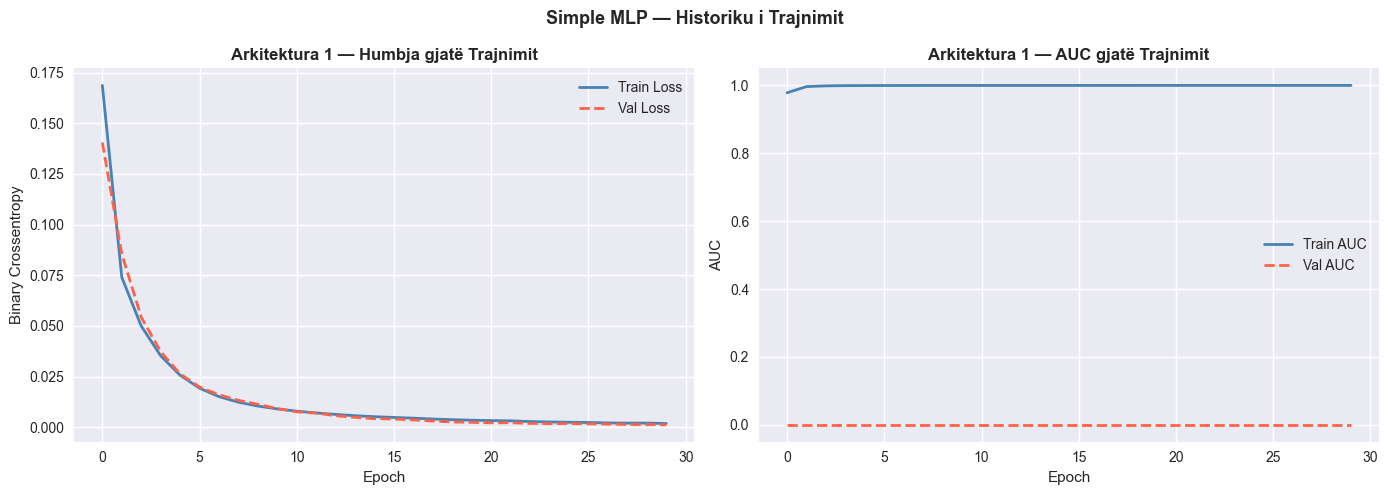

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history1.history['loss'],     color='steelblue', linewidth=2, label='Train Loss')
axes[0].plot(history1.history['val_loss'], color='tomato',    linewidth=2, label='Val Loss', linestyle='--')
axes[0].set_title('Arkitektura 1 — Humbja gjatë Trajnimit', fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Binary Crossentropy')
axes[0].legend()

axes[1].plot(history1.history['auc'],     color='steelblue', linewidth=2, label='Train AUC')
axes[1].plot(history1.history['val_auc'], color='tomato',    linewidth=2, label='Val AUC', linestyle='--')
axes[1].set_title('Arkitektura 1 — AUC gjatë Trajnimit', fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('AUC')
axes[1].legend()

plt.suptitle('Simple MLP — Historiku i Trajnimit', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../images/nn1_training_history.png', dpi=150, bbox_inches='tight')
plt.show()

## 2. Arkitektura 2 — Deep MLP me Regularizim

**Struktura:**
```
Input(30)
  → Dense(128, ReLU) → BatchNormalization → Dropout(0.3)
  → Dense(64,  ReLU) → BatchNormalization → Dropout(0.3)
  → Dense(32,  ReLU)
  → Dense(1,   Sigmoid)
```

**Ndryshimet kryesore ndaj Arkitekturës 1:**
- **Shtresa më të thella (128→64→32)** — kapacitet më i madh për lidhje jolineare
- **BatchNormalization** — normalizon aktivizimet pas çdo shtrese, stabilizon trajnimin dhe lejon learning rate më të lartë
- **Dropout(0.3)** — çaktivizon 30% neurone rastësisht gjatë trajnimit, parandalon overfitting
- **lr=0.0005** — learning rate më i vogël — ndërvepron mirë me BatchNorm
- **patience=15** — i japim model-it kohë shtesë pasi BatchNorm ka konvergjencë më të ngadaltë

In [6]:
def build_deep_mlp(input_dim):
    model = keras.Sequential([
        layers.Input(shape=(input_dim,)),

        layers.Dense(128, activation='relu'),
        layers.BatchNormalization(),
        layers.Dropout(0.3),

        layers.Dense(64, activation='relu'),
        layers.BatchNormalization(),
        layers.Dropout(0.3),

        layers.Dense(32, activation='relu'),

        layers.Dense(1, activation='sigmoid')
    ], name='Deep_MLP')

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=0.0005),
        loss='binary_crossentropy',
        metrics=[
            keras.metrics.AUC(name='auc'),
            keras.metrics.Precision(name='precision'),
            keras.metrics.Recall(name='recall')
        ]
    )
    return model

model2 = build_deep_mlp(INPUT_DIM)
model2.summary()

Model: "Deep_MLP"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 128)            │         2,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 13,825 (54.00 KB)

 Trainable params: 13,441 (52.50 KB)

 Non-trainable params: 384 (1.50 KB)

In [7]:
callbacks2 = [
    EarlyStopping(monitor='val_loss', patience=7, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=4, min_lr=1e-7, verbose=1)
]

history2 = model2.fit(
    X_train, y_train,
    epochs=30,
    batch_size=2048,
    validation_split=0.1,
    class_weight=class_weight_dict,
    callbacks=callbacks2,
    verbose=1
)

print(f'\nTrajnimi u ndal në epoch: {len(history2.history["loss"])}')

Epoch 1/30
150/150 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - auc: 0.9729 - loss: 0.1974 - precision: 0.7994 - recall: 0.9039 - val_auc: 0.0000e+00 - val_loss: 0.1497 - val_precision: 1.0000 - val_recall: 0.9226 - learning_rate: 5.0000e-04
Epoch 2/30
150/150 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - auc: 0.9944 - loss: 0.0844 - precision: 0.9374 - recall: 0.9492 - val_auc: 0.0000e+00 - val_loss: 0.0922 - val_precision: 1.0000 - val_recall: 0.9600 - learning_rate: 5.0000e-04
Epoch 3/30
150/150 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - auc: 0.9972 - loss: 0.0623 - precision: 0.9472 - recall: 0.9663 - val_auc: 0.0000e+00 - val_loss: 0.0455 - val_precision: 1.0000 - val_recall: 0.9822 - learning_rate: 5.0000e-04
Epoch 4/30
150/150 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - auc: 0.9983 - loss: 0.0483 - precision: 0.9556 - recall: 0.9763 - val_auc: 0.0000e+00 - val_loss: 0.0248 - val_precision: 1.0000 - val_recall: 0.9927 - learning_rate: 5.0000e-04
Epoch 5/30
150/150 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - auc: 0.9989 - 

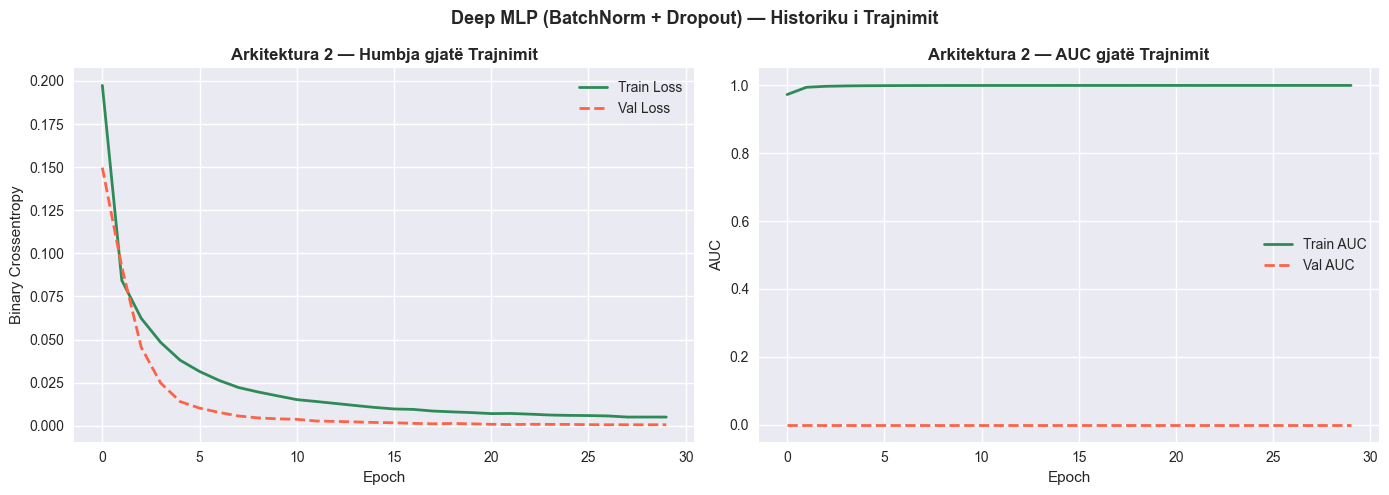

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history2.history['loss'],     color='seagreen', linewidth=2, label='Train Loss')
axes[0].plot(history2.history['val_loss'], color='tomato',   linewidth=2, label='Val Loss', linestyle='--')
axes[0].set_title('Arkitektura 2 — Humbja gjatë Trajnimit', fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Binary Crossentropy')
axes[0].legend()

axes[1].plot(history2.history['auc'],     color='seagreen', linewidth=2, label='Train AUC')
axes[1].plot(history2.history['val_auc'], color='tomato',   linewidth=2, label='Val AUC', linestyle='--')
axes[1].set_title('Arkitektura 2 — AUC gjatë Trajnimit', fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('AUC')
axes[1].legend()

plt.suptitle('Deep MLP (BatchNorm + Dropout) — Historiku i Trajnimit', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../images/nn2_training_history.png', dpi=150, bbox_inches='tight')
plt.show()

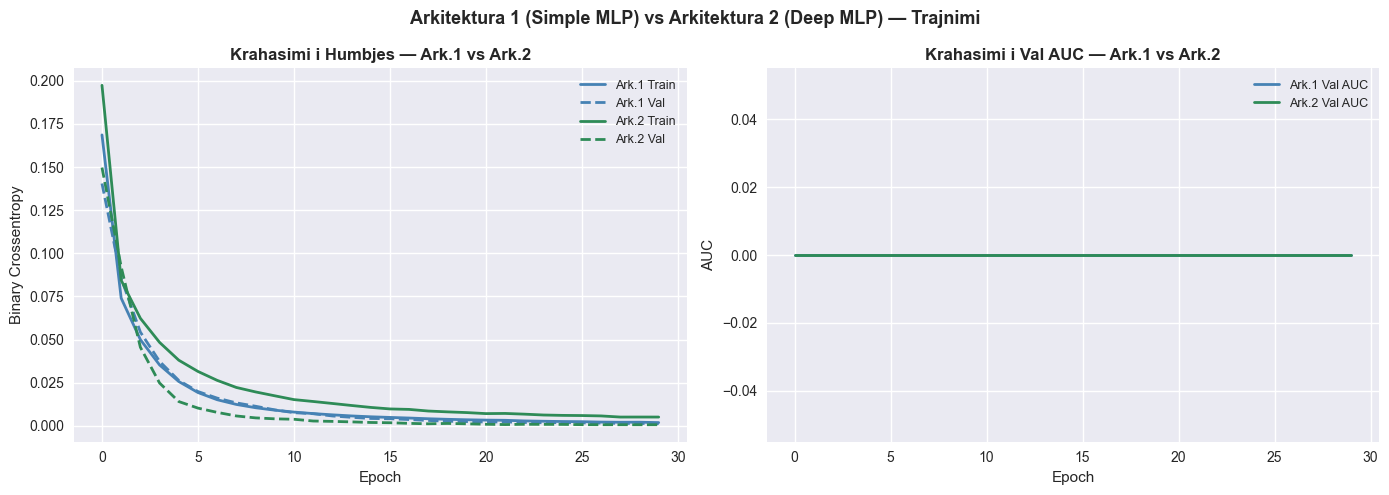

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history1.history['loss'],     color='steelblue', linewidth=2, label='Ark.1 Train')
axes[0].plot(history1.history['val_loss'], color='steelblue', linewidth=2, label='Ark.1 Val',   linestyle='--')
axes[0].plot(history2.history['loss'],     color='seagreen',  linewidth=2, label='Ark.2 Train')
axes[0].plot(history2.history['val_loss'], color='seagreen',  linewidth=2, label='Ark.2 Val',   linestyle='--')
axes[0].set_title('Krahasimi i Humbjes — Ark.1 vs Ark.2', fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Binary Crossentropy')
axes[0].legend(fontsize=9)

axes[1].plot(history1.history['val_auc'], color='steelblue', linewidth=2, label='Ark.1 Val AUC')
axes[1].plot(history2.history['val_auc'], color='seagreen',  linewidth=2, label='Ark.2 Val AUC')
axes[1].set_title('Krahasimi i Val AUC — Ark.1 vs Ark.2', fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('AUC')
axes[1].legend(fontsize=9)

plt.suptitle('Arkitektura 1 (Simple MLP) vs Arkitektura 2 (Deep MLP) — Trajnimi',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../images/nn_training_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## 3. Vlerësimi i Modeleve në Test Set

Vlerësojmë të dy arkitekturat në **test set** (real-world distribution, pa SMOTE) me:
- **Confusion Matrix** — True/False Positives dhe Negatives
- **Classification Report** — Precision, Recall, F1 për secilën klasë
- **ROC Curve + AUC** — performanca e diskriminimit

> Metrika kryesore: **Recall** (fraud i pazbuluar = dëm financiar direkt)

In [10]:
y_prob1 = model1.predict(X_test, verbose=0).flatten()
y_pred1 = (y_prob1 >= 0.5).astype(int)

acc1  = accuracy_score(y_test, y_pred1)
prec1 = precision_score(y_test, y_pred1)
rec1  = recall_score(y_test, y_pred1)
f1_1  = f1_score(y_test, y_pred1)
auc1  = roc_auc_score(y_test, y_prob1)

print('=' * 55)
print('METRIKAT — ARKITEKTURA 1: Simple MLP (Test Set)')
print('=' * 55)
print(f'Accuracy  : {acc1:.4f}')
print(f'Precision : {prec1:.4f}')
print(f'Recall    : {rec1:.4f}')
print(f'F1-score  : {f1_1:.4f}')
print(f'ROC-AUC   : {auc1:.4f}')
print(f'\n{classification_report(y_test, y_pred1, target_names=["Legjitime", "Mashtruese"])}')

METRIKAT — ARKITEKTURA 1: Simple MLP (Test Set)
Accuracy  : 0.9986
Precision : 0.5649
Recall    : 0.7789
F1-score  : 0.6549
ROC-AUC   : 0.9525

              precision    recall  f1-score   support

   Legjitime       1.00      1.00      1.00     56651
  Mashtruese       0.56      0.78      0.65        95

    accuracy                           1.00     56746
   macro avg       0.78      0.89      0.83     56746
weighted avg       1.00      1.00      1.00     56746



In [11]:
y_prob2 = model2.predict(X_test, verbose=0).flatten()
y_pred2 = (y_prob2 >= 0.5).astype(int)

acc2  = accuracy_score(y_test, y_pred2)
prec2 = precision_score(y_test, y_pred2)
rec2  = recall_score(y_test, y_pred2)
f1_2  = f1_score(y_test, y_pred2)
auc2  = roc_auc_score(y_test, y_prob2)

print('=' * 55)
print('METRIKAT — ARKITEKTURA 2: Deep MLP (Test Set)')
print('=' * 55)
print(f'Accuracy  : {acc2:.4f}')
print(f'Precision : {prec2:.4f}')
print(f'Recall    : {rec2:.4f}')
print(f'F1-score  : {f1_2:.4f}')
print(f'ROC-AUC   : {auc2:.4f}')
print(f'\n{classification_report(y_test, y_pred2, target_names=["Legjitime", "Mashtruese"])}')

METRIKAT — ARKITEKTURA 2: Deep MLP (Test Set)
Accuracy  : 0.9989
Precision : 0.6333
Recall    : 0.8000
F1-score  : 0.7070
ROC-AUC   : 0.9489

              precision    recall  f1-score   support

   Legjitime       1.00      1.00      1.00     56651
  Mashtruese       0.63      0.80      0.71        95

    accuracy                           1.00     56746
   macro avg       0.82      0.90      0.85     56746
weighted avg       1.00      1.00      1.00     56746



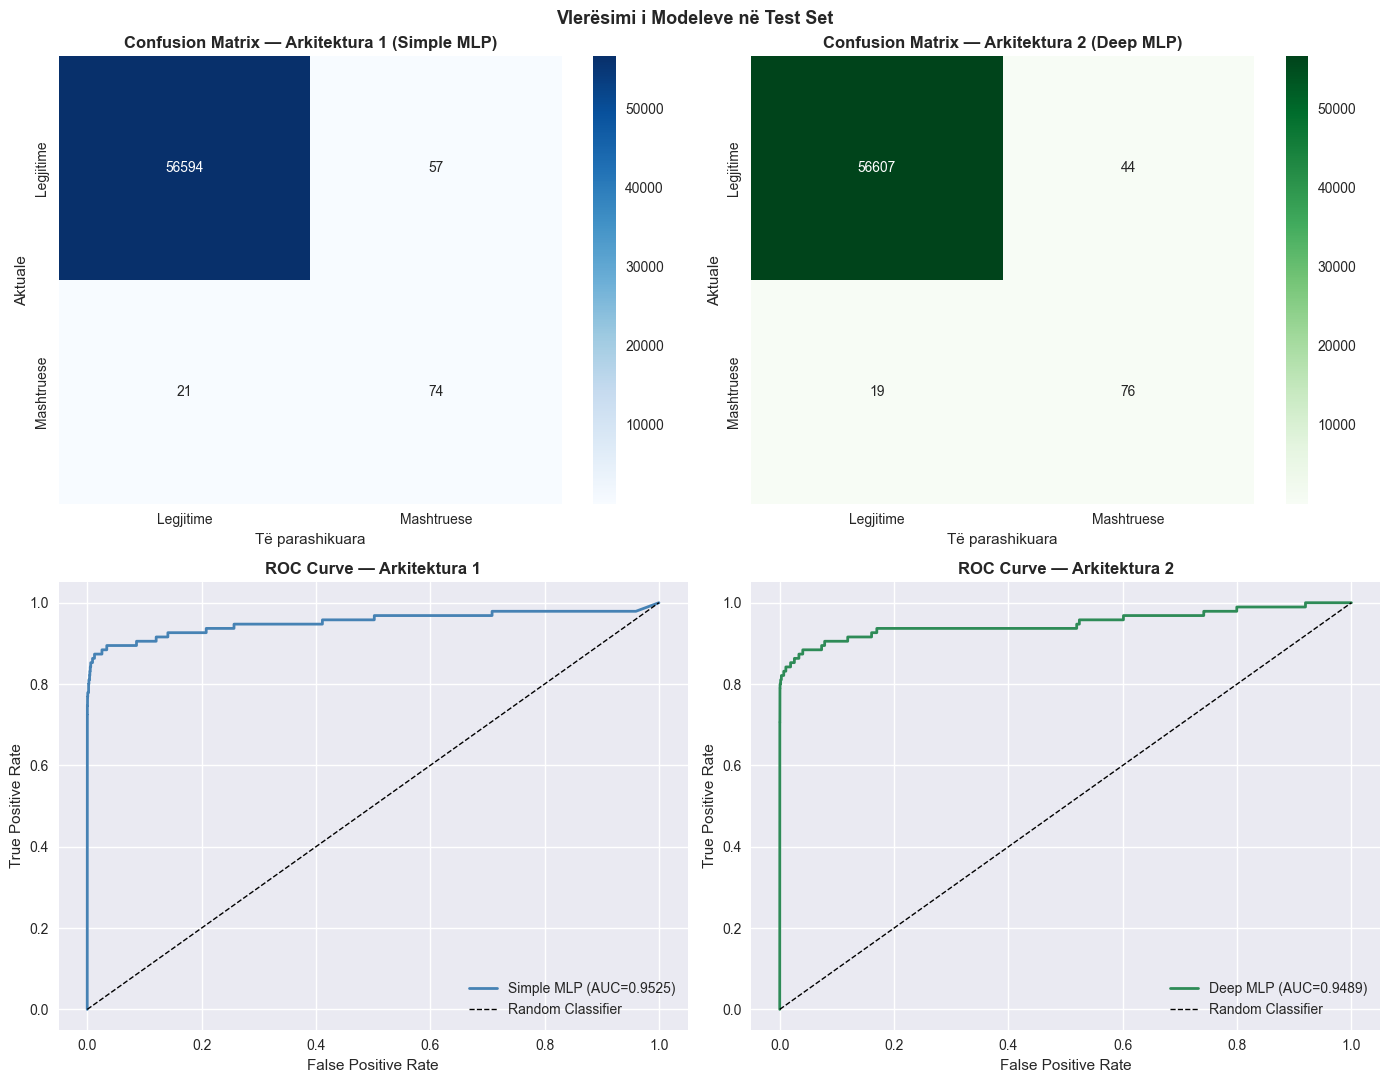

In [12]:
fig, axes = plt.subplots(2, 2, figsize=(14, 11))

cm1 = confusion_matrix(y_test, y_pred1)
sns.heatmap(cm1, annot=True, fmt='d', cmap='Blues', ax=axes[0, 0],
            xticklabels=['Legjitime', 'Mashtruese'],
            yticklabels=['Legjitime', 'Mashtruese'])
axes[0, 0].set_title('Confusion Matrix — Arkitektura 1 (Simple MLP)', fontweight='bold')
axes[0, 0].set_ylabel('Aktuale')
axes[0, 0].set_xlabel('Të parashikuara')

cm2 = confusion_matrix(y_test, y_pred2)
sns.heatmap(cm2, annot=True, fmt='d', cmap='Greens', ax=axes[0, 1],
            xticklabels=['Legjitime', 'Mashtruese'],
            yticklabels=['Legjitime', 'Mashtruese'])
axes[0, 1].set_title('Confusion Matrix — Arkitektura 2 (Deep MLP)', fontweight='bold')
axes[0, 1].set_ylabel('Aktuale')
axes[0, 1].set_xlabel('Të parashikuara')

fpr1, tpr1, _ = roc_curve(y_test, y_prob1)
axes[1, 0].plot(fpr1, tpr1, color='steelblue', linewidth=2, label=f'Simple MLP (AUC={auc1:.4f})')
axes[1, 0].plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random Classifier')
axes[1, 0].set_title('ROC Curve — Arkitektura 1', fontweight='bold')
axes[1, 0].set_xlabel('False Positive Rate')
axes[1, 0].set_ylabel('True Positive Rate')
axes[1, 0].legend()

fpr2, tpr2, _ = roc_curve(y_test, y_prob2)
axes[1, 1].plot(fpr2, tpr2, color='seagreen', linewidth=2, label=f'Deep MLP (AUC={auc2:.4f})')
axes[1, 1].plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random Classifier')
axes[1, 1].set_title('ROC Curve — Arkitektura 2', fontweight='bold')
axes[1, 1].set_xlabel('False Positive Rate')
axes[1, 1].set_ylabel('True Positive Rate')
axes[1, 1].legend()

plt.suptitle('Vlerësimi i Modeleve në Test Set', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../images/nn_evaluation.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Krahasimi Final i Dy Arkitekturave
Krahasojmë të dy modelet me të gjitha metrikat dhe identifikojmë fituesin bazuar në **F1-score** (ekuilibri mes Recall dhe Precision për fraud detection).

In [13]:
comparison_nn = pd.DataFrame({
    'Modeli'       : ['Arkitektura 1 (Simple MLP)', 'Arkitektura 2 (Deep MLP)'],
    'Struktura'    : ['64→32→1', '128→BN→Do→64→BN→Do→32→1'],
    'Parametra'    : [model1.count_params(), model2.count_params()],
    'Accuracy'     : [acc1,  acc2],
    'Precision'    : [prec1, prec2],
    'Recall'       : [rec1,  rec2],
    'F1-score'     : [f1_1,  f1_2],
    'ROC-AUC'      : [auc1,  auc2]
})

print('=' * 75)
print('TABELA KRAHASUESE — ARKITEKTURA 1 vs ARKITEKTURA 2')
print('=' * 75)
print(comparison_nn[['Modeli', 'Accuracy', 'Precision', 'Recall', 'F1-score', 'ROC-AUC']].round(4).to_string(index=False))

best_idx  = comparison_nn['F1-score'].idxmax()
best_name = comparison_nn.loc[best_idx, 'Modeli']
best_f1   = comparison_nn.loc[best_idx, 'F1-score']
best_auc  = comparison_nn.loc[best_idx, 'ROC-AUC']
print(f'\nModeli fitues (F1-score): {best_name}')
print(f'  F1-score : {best_f1:.4f}')
print(f'  ROC-AUC  : {best_auc:.4f}')

TABELA KRAHASUESE — ARKITEKTURA 1 vs ARKITEKTURA 2
                    Modeli  Accuracy  Precision  Recall  F1-score  ROC-AUC
Arkitektura 1 (Simple MLP)    0.9986     0.5649  0.7789    0.6549   0.9525
  Arkitektura 2 (Deep MLP)    0.9989     0.6333  0.8000    0.7070   0.9489

Modeli fitues (F1-score): Arkitektura 2 (Deep MLP)
  F1-score : 0.7070
  ROC-AUC  : 0.9489


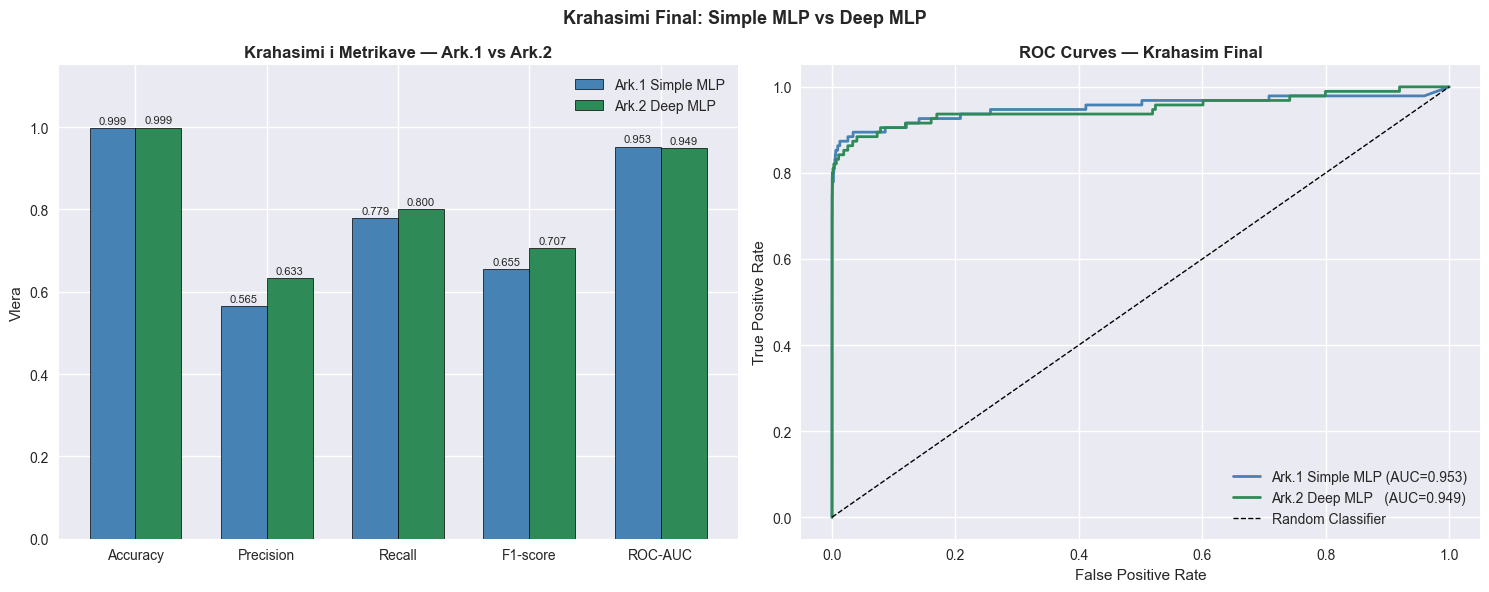

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

metrics  = ['Accuracy', 'Precision', 'Recall', 'F1-score', 'ROC-AUC']
vals1    = [acc1,  prec1, rec1,  f1_1,  auc1]
vals2    = [acc2,  prec2, rec2,  f1_2,  auc2]
x = np.arange(len(metrics))
w = 0.35

bars1 = axes[0].bar(x - w/2, vals1, w, label='Ark.1 Simple MLP', color='steelblue', edgecolor='black', linewidth=0.5)
bars2 = axes[0].bar(x + w/2, vals2, w, label='Ark.2 Deep MLP',   color='seagreen',  edgecolor='black', linewidth=0.5)
axes[0].set_xticks(x)
axes[0].set_xticklabels(metrics)
axes[0].set_ylim(0, 1.15)
axes[0].set_title('Krahasimi i Metrikave — Ark.1 vs Ark.2', fontweight='bold')
axes[0].set_ylabel('Vlera')
axes[0].legend()
for bar, val in zip(bars1, vals1):
    axes[0].text(bar.get_x() + bar.get_width()/2, val + 0.01, f'{val:.3f}', ha='center', fontsize=8)
for bar, val in zip(bars2, vals2):
    axes[0].text(bar.get_x() + bar.get_width()/2, val + 0.01, f'{val:.3f}', ha='center', fontsize=8)

axes[1].plot(fpr1, tpr1, color='steelblue', linewidth=2, label=f'Ark.1 Simple MLP (AUC={auc1:.3f})')
axes[1].plot(fpr2, tpr2, color='seagreen',  linewidth=2, label=f'Ark.2 Deep MLP   (AUC={auc2:.3f})')
axes[1].plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random Classifier')
axes[1].set_title('ROC Curves — Krahasim Final', fontweight='bold')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].legend()

plt.suptitle('Krahasimi Final: Simple MLP vs Deep MLP', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../images/nn_final_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Ruajtja e Modelit më të Mirë

Modeli me **F1-score** më të lartë ruhet si `models/best_model.h5` për përdorim në projektin LAB2.

Format `.h5` (HDF5) ruan të gjithë arkitekturën + peshat + konfigurimin e optimizerit — mund të ngarkohet plotësisht me `keras.models.load_model()`.

In [15]:
best_model = model1 if f1_1 >= f1_2 else model2
best_label = 'Simple MLP (Ark.1)' if f1_1 >= f1_2 else 'Deep MLP (Ark.2)'
best_f1_val = max(f1_1, f1_2)
best_auc_val = auc1 if f1_1 >= f1_2 else auc2

MODELS_DIR = '../models'
os.makedirs(MODELS_DIR, exist_ok=True)
MODEL_PATH = f'{MODELS_DIR}/best_model.h5'

best_model.save(MODEL_PATH)

size_kb = os.path.getsize(MODEL_PATH) / 1024
print('=' * 55)
print('RUAJTJA E MODELIT MË TË MIRË — SUKSES')
print('=' * 55)
print(f'Modeli fitues : {best_label}')
print(f'F1-score      : {best_f1_val:.4f}')
print(f'ROC-AUC       : {best_auc_val:.4f}')
print(f'Path          : {MODEL_PATH}')
print(f'Madhësia      : {size_kb:.1f} KB')

loaded = keras.models.load_model(MODEL_PATH)
print(f'\nVerifikim — modeli u ngarkua me sukses: {loaded.name}')

RUAJTJA E MODELIT MË TË MIRË — SUKSES
Modeli fitues : Deep MLP (Ark.2)
F1-score      : 0.7070
ROC-AUC       : 0.9489
Path          : ../models/best_model.h5
Madhësia      : 213.7 KB

Verifikim — modeli u ngarkua me sukses: Deep_MLP


## 6. Përfundime

### Krahasimi i dy arkitekturave:

| Aspekti | Arkitektura 1 (Simple MLP) | Arkitektura 2 (Deep MLP) |
|---|---|---|
| Struktura | 64→32→1 | 128→BN→Drop→64→BN→Drop→32→1 |
| Regularizim | asnjë | BatchNorm + Dropout(0.3) |
| Learning rate | 0.001 | 0.0005 |
| Kompleksiteti | i ulët | i lartë |

### Metrikat kryesore për fraud detection:
> **Recall** — prioritet maksimal: fraud i pazbuluar = dëm financiar direkt  
> **F1-score** — ekuilibri mes Recall dhe Precision  
> **ROC-AUC** — performanca e përgjithshme e diskriminimit

### Modeli i ruajtur:
Modeli me F1-score më të lartë është ruajtur si **`models/best_model.h5`** dhe mund të ngarkohet me:
```python
from tensorflow import keras
model = keras.models.load_model('models/best_model.h5')
```